In [1]:
%load_ext autoreload
%autoreload 2

save_plot = False


In [2]:
import sys
sys.path.append('..')
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import json
import seaborn as sns
pd.set_option('display.max_rows', 100)
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
new_metrics = pd.read_parquet("new_metrics_large_all.parquet")
new_metrics['DataSet'] = new_metrics['DataSet'].replace({
    'HCT_large': 'HCT116',
    'HEK_large': 'HEK293T',
    'K562_large': 'K562',
    'hepg2_large': 'HepG2',
    'jurkat_large': 'Jurkat',
    'rpe1_large': 'RPE1',
})

In [5]:
gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_large_detail.parquet")

In [6]:
psi_nosplit = []
for deg in [10000]:
    gp_tm = gene_perf[(gene_perf['method'] == 'trainMean') & (gene_perf['deg_rank'] <= deg)].copy()

    # M = mean delta across ALL perturbations per (dataset, gene) — no split holdout
    gene_avg = (gp_tm
        .groupby(['dataset', 'gene'])['mean_true_delta']
        .mean()
        .rename('avg_gene_delta')
    )

    gp_merged = gp_tm.merge(gene_avg, on=['dataset', 'gene'], how='left')
    gp_merged['residual'] = gp_merged['mean_true_delta'] - gp_merged['avg_gene_delta']

    def compute_psi_components(g):
        x = g['mean_true_delta'].values
        m = g['avg_gene_delta'].values
        mask = ~np.isnan(x) & ~np.isnan(m)
        x, m = x[mask], m[mask]
        if len(x) < 2:
            return pd.Series({'PSI': np.nan, 'var_x': np.nan, 'var_m': np.nan, 'cov_xm': np.nan, 'corr_xm': np.nan})
        var_x = np.var(x, ddof=1)
        var_m = np.var(m, ddof=1)
        cov_xm = np.cov(x, m, ddof=1)[0, 1]
        corr_xm = cov_xm / np.sqrt(var_x * var_m) if var_x > 0 and var_m > 0 else np.nan
        psi = np.var(x - m, ddof=1) / var_x if var_x > 0 else np.nan
        return pd.Series({'PSI': psi, 'var_x': var_x, 'var_m': var_m, 'cov_xm': cov_xm, 'corr_xm': corr_xm})


    psi_deg = (gp_merged
        .groupby(['dataset', 'perturbation'])
        .apply(compute_psi_components, include_groups=False)
        .reset_index()
    )
    psi_deg['DEG'] = deg
    psi_nosplit.append(psi_deg)
    print(f"DEG={deg}: {len(psi_deg)} entries")

psi_nosplit = pd.concat(psi_nosplit, ignore_index=True)
psi_ns = psi_nosplit[psi_nosplit['DEG'] == 2000].drop(columns='DEG').reset_index(drop=True)

# Verify Var(M) is constant per dataset
print("\nVar(M) per dataset (should be constant):")
print(psi_ns.groupby('dataset')['var_m'].std())


DEG=10000: 13659 entries

Var(M) per dataset (should be constant):
Series([], Name: var_m, dtype: float64)


In [7]:
psi_ns = psi_nosplit[psi_nosplit['DEG'] == 10000].drop(columns='DEG').reset_index(drop=True)

# Verify Var(M) is constant per dataset
print("\nVar(M) per dataset (should be constant):")
print(psi_ns.groupby('dataset')['var_m'].std())


Var(M) per dataset (should be constant):
dataset
HCT_large       3.343666e-12
HEK_large       1.525080e-12
K562_large      1.460448e-11
hepg2_large     5.867258e-11
jurkat_large    2.834177e-11
rpe1_large      1.082452e-10
Name: var_m, dtype: float64


In [8]:
psi = psi_ns

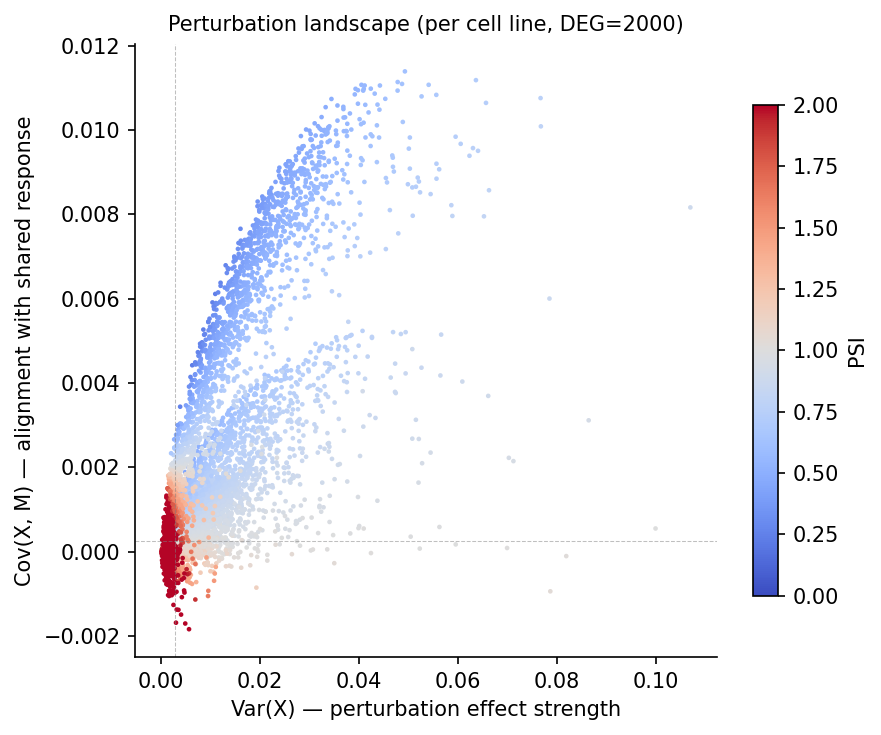

In [10]:
# 2D scatter: Var(X) vs Cov(X,M), colored by PSI
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

sc = ax.scatter(psi['var_x'], psi['cov_xm'], c=psi['PSI'],
                cmap='coolwarm', s=5, alpha=1, edgecolors='none',
                vmin=0, vmax=2)

plt.colorbar(sc, ax=ax, label='PSI', shrink=0.8)
ax.set_xlabel('Var(X) — perturbation effect strength', fontsize=10)
ax.set_ylabel('Cov(X, M) — alignment with shared response', fontsize=10)
ax.set_title('Perturbation landscape (per cell line, DEG=2000)', fontsize=10)

# Add quadrant lines at medians
ax.axhline(psi['cov_xm'].median(), color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(psi['var_x'].median(), color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# Label quadrants
kw = dict(fontsize=7, ha='center', alpha=1)
xlo, xhi = psi['var_x'].quantile(0.15), psi['var_x'].quantile(0.85)
ylo, yhi = psi['cov_xm'].quantile(0.15), psi['cov_xm'].quantile(0.85)
# ax.text(xhi, yhi, 'Sledgehammers\n(strong + generic)', **kw)
# ax.text(xhi, ylo, 'Scalpels\n(strong + distinct)', **kw)
# ax.text(xlo, yhi, 'Weak generic', **kw)
# ax.text(xlo, ylo, 'Weak subtle', **kw)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [15]:
# Split by median into quadrants
var_x_med = psi_ns['var_x'].median()
corr_xm_med = psi_ns['corr_xm'].median()

def assign_quadrant(row):
    hi_var = row['var_x'] > var_x_med
    hi_corr = row['corr_xm'] > corr_xm_med
    if hi_var and hi_corr: return 'Sledgehammer (strong + generic)'
    elif hi_var and not hi_corr: return 'Scalpel (strong + distinct)'
    elif not hi_var and hi_corr: return 'Weak generic'
    else: return 'Weak subtle'

psi_ns['quadrant'] = psi_ns.apply(assign_quadrant, axis=1)

print(psi_ns['quadrant'].value_counts())
print(f"\nMedian Var(X): {var_x_med:.6f}")
print(f"Median Corr(X,M): {corr_xm_med:.4f}")

quadrant
Weak subtle                        5038
Sledgehammer (strong + generic)    5037
Weak generic                       1792
Scalpel (strong + distinct)        1792
Name: count, dtype: int64

Median Var(X): 0.002825
Median Corr(X,M): 0.2906


In [13]:
# Look at which perturbations consistently fall in each quadrant across cell lines
quad_counts = (psi_ns
    .groupby(['perturbation', 'quadrant'])
    .size()
    .unstack(fill_value=0)
)
quad_counts['dominant'] = quad_counts.idxmax(axis=1)
quad_counts['n_celllines'] = quad_counts.drop(columns='dominant').sum(axis=1)

# Perturbations that are in the same quadrant across all cell lines
consistent = quad_counts[quad_counts.max(axis=1, numeric_only=True) == quad_counts['n_celllines']]
print(f"\nConsistently in same quadrant across all cell lines: {len(consistent)}")
print(consistent['dominant'].value_counts())


Consistently in same quadrant across all cell lines: 2278
dominant
Sledgehammer (strong + generic)    1063
Weak subtle                         853
Scalpel (strong + distinct)         260
Weak generic                        102
Name: count, dtype: int64


In [14]:
# Top examples per quadrant (sorted appropriately)
sort_config = {
    'Sledgehammer (strong + generic)': ('cov_xm', False),   # highest cov
    'Scalpel (strong + distinct)':     ('cov_xm', True),    # lowest cov (most distinct)
    'Weak generic':                    ('cov_xm', False),   # highest cov among weak
    'Weak subtle':                     ('cov_xm', True),    # lowest cov among weak
}

for q, (sort_col, asc) in sort_config.items():
    perts = consistent[consistent['dominant'] == q].index.tolist()
    print(f"\n--- {q} ({len(perts)} perturbations) ---")
    sub = psi_ns[psi_ns['perturbation'].isin(perts)].groupby('perturbation')[['var_x', 'cov_xm', 'PSI']].median()
    print(sub.sort_values(sort_col, ascending=asc).head(50))


--- Sledgehammer (strong + generic) (1063 perturbations) ---
                 var_x    cov_xm       PSI
perturbation                              
MED30         0.025457  0.002608  0.823780
MED9          0.020744  0.002179  0.809916
MED21         0.016007  0.002046  0.822066
MED7          0.020153  0.002016  0.789561
EIF2B3        0.020733  0.001952  0.808350
SMC3          0.015199  0.001947  0.869575
MED17         0.014632  0.001818  0.809150
EXOSC2        0.014103  0.001773  0.839369
EXOSC8        0.012537  0.001760  0.833008
TAF12         0.017434  0.001737  0.846876
SUPT5H        0.025646  0.001736  0.837653
MED6          0.011078  0.001732  0.775088
EXOSC9        0.012553  0.001731  0.843000
EIF2B2        0.014155  0.001713  0.795178
EXOSC3        0.013238  0.001678  0.849634
EIF3D         0.014267  0.001650  0.801053
EXOSC4        0.012655  0.001647  0.856947
MED19         0.008362  0.001638  0.761887
RPL17         0.026449  0.001612  0.853335
HSPA9         0.015038  0.001608  0